# ANNDL Project  

The project has three parts: classification, segmentation and detection.

Please read the code in the notebook and make sure you understand what is expected of you before you start modifying it.

Some helper code is in place already to help you through the most tedious part of the data loading and preprocessing.


# 0. Getting started
## Instructions for use in Google Colab

You can safely ignore this section if you are not using Google Colab.

Before you begin, upload the VOC tar file to your Google Drive. Then mount drive in colab:

In [1]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


You can extract the tar file to your drive, but for perfomance reasons, we extract to colab's local storage

Note: make sure you adapt the paths below to match your own.

In [2]:
# Make sure to update the path to your VOC tar file if it's different
!mkdir -p '/content/voc'
!tar -xf '/content/drive/MyDrive/VOCtrainval_11-May-2012.tar' -C "/content/voc/"

## Instructions to run locally

You can safely ignore this section if you are not running the notebook locally.

First, make sure you extract the downloaded tar file.

Then, specify the folder the path to the base folder.

# 1. Image classification

## Preprocessing

First, make sure you extract the downloaded tar file.

Then, specify in the cell below the folder in which you have extracted the tar file.

In [3]:
# Updated to point to the extracted folder in Colab local storage
path_to_VOC_folder = '/content/voc/VOCdevkit/VOC2012'

These functions will help you to create your data pipeline.  
`get_image_paths` is used to find the paths to the images and annotations.
`xml_to_labels` will turn the list of annotations into a matrix of size [samples,classes], where the colums persent a binary indication of presence of that class for that sample.

You can select the classes you want to include by passing a list of class names to both methods using the filter argument.

In [4]:
import os
import keras
from typing import List
import tensorflow as tf
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

In [5]:
_IMAGE_SHAPE=(256,256) # Increased from 180 — better spatial detail for segmentation
_BATCH_SIZE=32

# 1. Image classification: multi-label multi-class classification

In this part, you will build a multi-label multi-class classification model. This means each image can have more than one class. Make sure you use appropriate loss and metrics.

## Preprocessing

In [6]:
_VOC_LABELS = (
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor",
)


def preprocess_classification_data(voc_root_folder):
    """
    Reads VOC annotations and returns a dictionary with:
      key   : image id
      value : {'path': image_path, 'classes': [list of classes in image]}
    """

    annotation_dir = os.path.join(voc_root_folder, "Annotations")
    image_dir = os.path.join(voc_root_folder, "JPEGImages")

    dataset = {}

    for xml_file in os.listdir(annotation_dir):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(annotation_dir, xml_file)

        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find("filename").text
        image_id = os.path.splitext(filename)[0]
        image_path = os.path.join(image_dir, filename)

        classes = []

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            classes.append(class_name)

        # Remove duplicates
        classes = list(set(classes))

        dataset[image_id] = {
            "path": image_path,
            "classes": classes
        }

    return dataset

In [7]:
# get the paths and labels:
image_classes = preprocess_classification_data('/content/voc/VOCdevkit/VOC2012')

In [8]:
# Example image
image_classes['2009_003541']

{'path': '/content/voc/VOCdevkit/VOC2012/JPEGImages/2009_003541.jpg',
 'classes': ['cat', 'sheep']}

Let's plot some images.

In [9]:
import random
import matplotlib.pyplot as plt
from PIL import Image


def show_random_images(dataset, n=4):

    keys = random.sample(list(dataset.keys()), n)

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    for ax, key in zip(axes, keys):

        sample = dataset[key]

        img = Image.open(sample["path"])

        ax.imshow(img)
        ax.axis("off")

        title = ", ".join(sample["classes"])
        ax.set_title(key + ": " + title, fontsize=10)

    plt.tight_layout()
    plt.show()

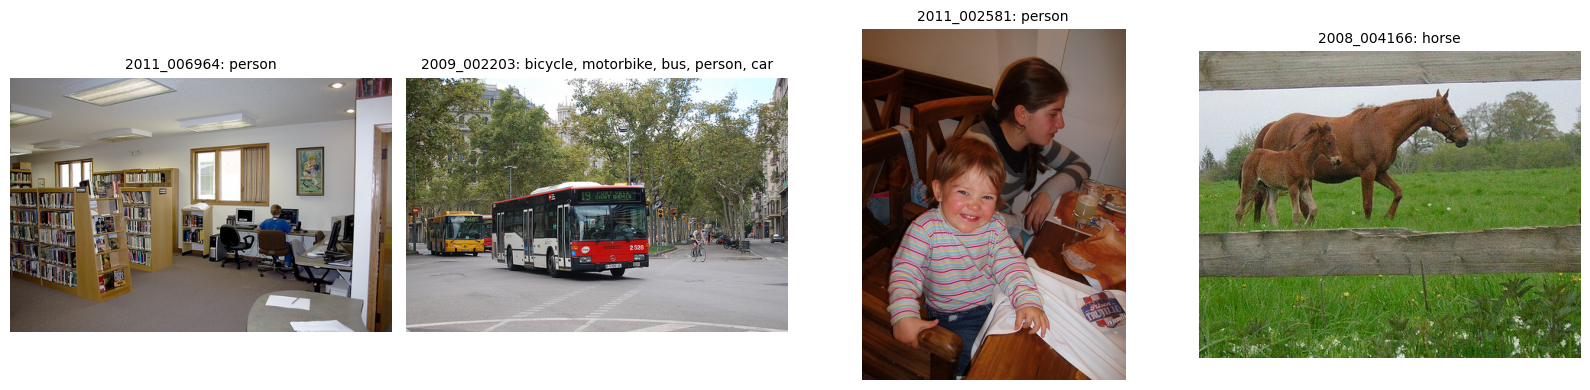

In [10]:
show_random_images(image_classes)

In [11]:
len(image_classes)

17125

Now it's your turn. Transform the data so you can feed it to Keras for multilabel, multiclass classification.

In [12]:
# ENTER YOUR CODE HERE TO TRANSFORM THE DATA FOR MULTILABEL CLASSIFICATION
from sklearn.preprocessing import MultiLabelBinarizer

# Keep label order fixed to VOC classes
mlb = MultiLabelBinarizer(classes=list(_VOC_LABELS))

image_ids = sorted(image_classes.keys())
image_paths = np.array([image_classes[img_id]["path"] for img_id in image_ids])
label_lists = [image_classes[img_id]["classes"] for img_id in image_ids]

# Multi-hot encoding: shape = (num_images, 20)
labels = mlb.fit_transform(label_lists).astype("float32")

print("Number of images:", len(image_paths))
print("Labels shape:", labels.shape)
print("Classes:", mlb.classes_)

# Quick sanity check
for i in range(3):
    active_classes = [mlb.classes_[j] for j in np.where(labels[i] == 1)[0]]
    print(f"{image_paths[i]} -> {active_classes}")

Number of images: 17125
Labels shape: (17125, 20)
Classes: ['aeroplane' 'bicycle' 'bird' 'boat' 'bottle' 'bus' 'car' 'cat' 'chair'
 'cow' 'diningtable' 'dog' 'horse' 'motorbike' 'person' 'pottedplant'
 'sheep' 'sofa' 'train' 'tvmonitor']
/content/voc/VOCdevkit/VOC2012/JPEGImages/2007_000027.jpg -> ['person']
/content/voc/VOCdevkit/VOC2012/JPEGImages/2007_000032.jpg -> ['aeroplane', 'person']
/content/voc/VOCdevkit/VOC2012/JPEGImages/2007_000033.jpg -> ['aeroplane']


Now split the data into train, validation and test sets.

In [13]:
# ENTER YOUR CODE HERE TO SPLIT THE DATA INTO TRAINING, VALIDATION AND TEST SETS
from sklearn.model_selection import train_test_split

SEED = 42

# First split: train vs temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.4,       # 60% train
    random_state=SEED,
    shuffle=True
)

# Second split: validation vs test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,       # 20% val, 20% test overall
    random_state=SEED,
    shuffle=True
)

print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")

print("Train labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)
print("Test labels shape:", test_labels.shape)

Train samples: 10275
Validation samples: 3425
Test samples: 3425
Train labels shape: (10275, 20)
Validation labels shape: (3425, 20)
Test labels shape: (3425, 20)


Below, there's two functions you can use as your data pipeline and an example of their usage (make sure the names of the variables you created in the previous step match)

In [14]:
IMG_SIZE = 224  # Increased from 180 — more detail for 20-class multilabel

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_tf_dataset(paths, labels, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [15]:
# Build TensorFlow datasets for training, validation and testing (make sure to replace the variables with your actual paths and labels)
train_ds = build_tf_dataset(train_paths, train_labels)
val_ds = build_tf_dataset(val_paths, val_labels, shuffle=False)
test_ds = build_tf_dataset(test_paths, test_labels, shuffle=False)

## Model

### 1.1. Create your own network from scratch

Create and train a convolutional neural network from scratch and build as good a model as you can!
You can take inspiration from existing architectures, examples from the book etc. but write the code to define all the layers yourself.
Use the techniques you have learned in the book and iterate on your design choices to show you know how to build a classifier, what to do to first overfit and then regularise the model, and use as many advanced features as you can, such as:
- Keras callbacks
- Data augmentation
- Dropout
- Batch normalisation
- Depthwise separable convolutions
- Residual connections


In [16]:
!pip install -q keras-cv

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

SEED = 42
keras.utils.set_random_seed(SEED)
print("GPUs:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 41.5 MB/s eta 0:00:00
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "v1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,412 (513.33 KB)

 Trainable params: 131,412 (513.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - auc: 0.4944 - binary_accuracy: 0.9234 - loss: 0.2662 - precision: 0.4822 - recall: 0.3411
Epoch 1: val_auc improved from None to 0.57061, saving model to v1.keras

Epoch 1: finished saving model to v1.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - auc: 0.5110 - binary_accuracy: 0.9344 - loss: 0.2180 - precision: 0.5463 - recall: 0.3285 - val_auc: 0.5706 - val_binary_accuracy: 0.9363 - val_loss: 0.2054 - val_precision: 0.5559 - val_recall: 0.3945 - learning_rate: 0.0010
Epoch 2/25
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc: 0.5768 - binary_accuracy: 0.9383 - loss: 0.1975 - precision: 0.6015 - recall: 0.3403
Epoch 2: val_auc improved from 0.57061 to 0.63819, saving model to v1.keras

Epoch 2: finished saving model to v1.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - auc: 0.5923 - binary_accuracy: 0.9377 - loss: 0.1974 - precision: 0.5926 - recall: 0.3299 - val_auc: 0.6382 - val_binary_accuracy: 0.9365 - val_loss: 0.2023 

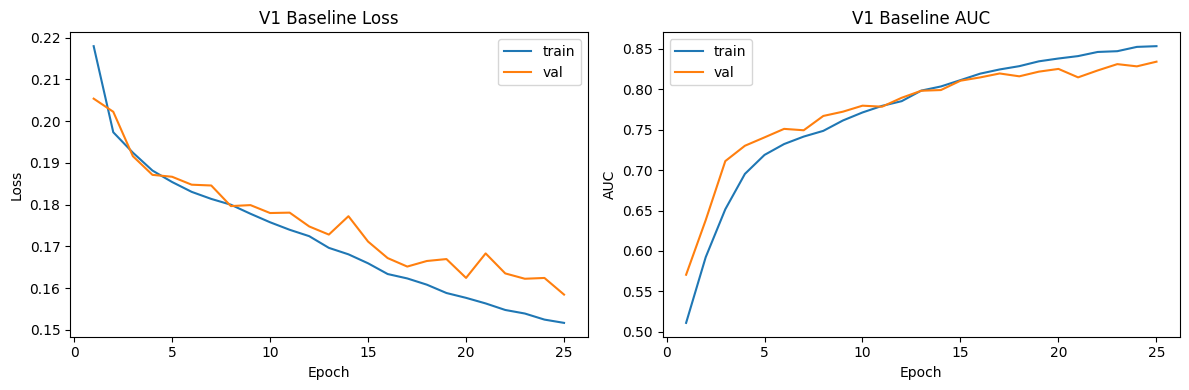

Model: "v2_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             

 Total params: 460,788 (1.76 MB)

 Trainable params: 459,828 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - auc: 0.5541 - binary_accuracy: 0.9170 - loss: 0.2469 - precision: 0.4521 - recall: 0.2948
Epoch 1: val_auc improved from None to 0.65750, saving model to v2.keras

Epoch 1: finished saving model to v2.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 61s 166ms/step - auc: 0.5949 - binary_accuracy: 0.9340 - loss: 0.2125 - precision: 0.5471 - recall: 0.2887 - val_auc: 0.6575 - val_binary_accuracy: 0.9312 - val_loss: 0.2104 - val_precision: 0.7241 - val_recall: 0.0089 - learning_rate: 0.0010
Epoch 2/25
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - auc: 0.6662 - binary_accuracy: 0.9386 - loss: 0.1956 - precision: 0.6172 - recall: 0.3108
Epoch 2: val_auc improved from 0.65750 to 0.74802, saving model to v2.keras

Epoch 2: finished saving model to v2.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 52s 162ms/step - auc: 0.6776 - binary_accuracy: 0.9392 - loss: 0.1929 - precision: 0.6243 - recall: 0.3140 - val_auc: 0.7480 - val_binary_accuracy: 0.9396 - val_loss: 0.1

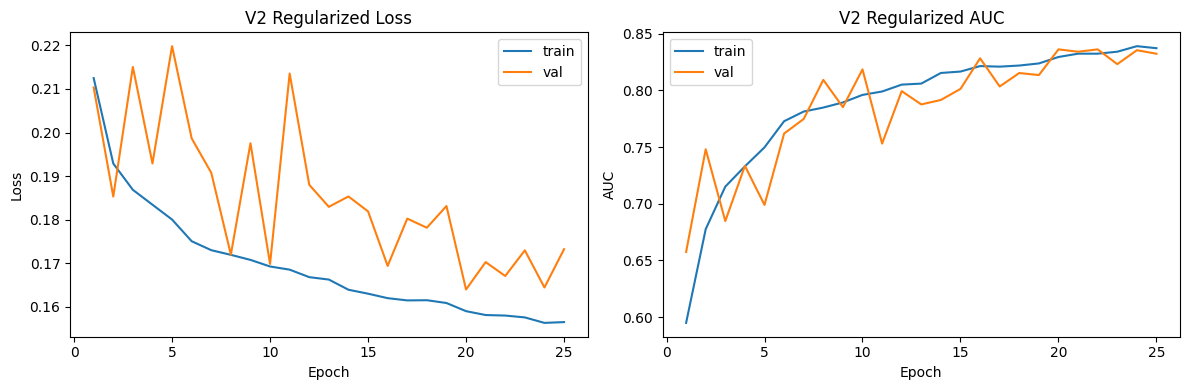

Model: "v3_separable_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │        864 │ augmentation[1][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 56, 56,    │      2,336 │ activation_4[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 56, 56,    │      4,672 │ activation_5[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 56, 56,    │      2,048 │ activation_4[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 56, 56,    │          0 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 28, 28,    │      8,768 │ dropout_6[0][0]   │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ separable_conv2d

 Total params: 858,260 (3.27 MB)

 Trainable params: 852,436 (3.25 MB)

 Non-trainable params: 5,824 (22.75 KB)

Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - auc: 0.5712 - binary_accuracy: 0.9215 - loss: 0.2400 - precision: 0.4756 - recall: 0.3021
Epoch 1: val_auc improved from None to 0.62615, saving model to v3.keras

Epoch 1: finished saving model to v3.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - auc: 0.6103 - binary_accuracy: 0.9347 - loss: 0.2108 - precision: 0.5567 - recall: 0.2905 - val_auc: 0.6262 - val_binary_accuracy: 0.9308 - val_loss: 0.2247 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - auc: 0.6788 - binary_accuracy: 0.9398 - loss: 0.1926 - precision: 0.6348 - recall: 0.3175
Epoch 2: val_auc improved from 0.62615 to 0.74863, saving model to v3.keras

Epoch 2: finished saving model to v3.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - auc: 0.7020 - binary_accuracy: 0.9402 - loss: 0.1897 - precision: 0.6443 - recall: 0.3108 - val_auc: 0.7486 - val_binary_accuracy: 0.9402 - val_loss:

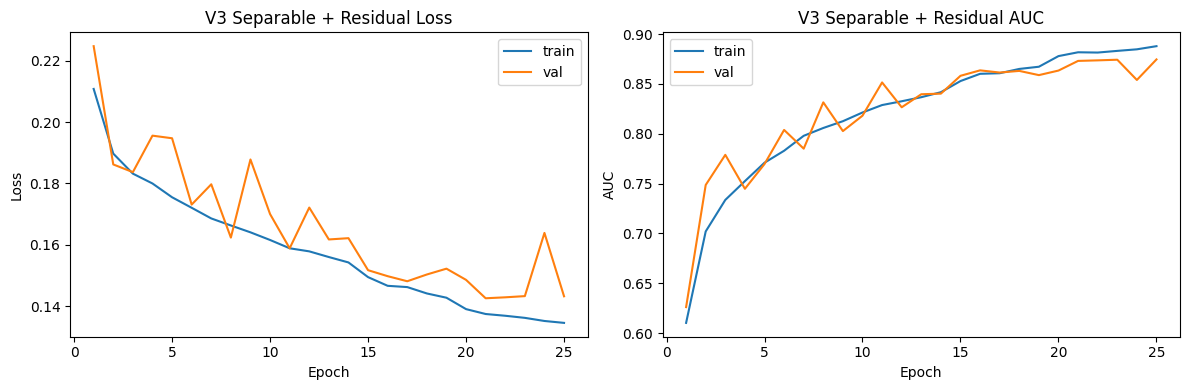


=== Comparison on test set ===
V1 Baseline               | AUC: 0.8450 | Precision: 0.7167 | Recall: 0.3725
V2 Regularized            | AUC: 0.8388 | Precision: 0.7636 | Recall: 0.3177
V3 Sep+Res                | AUC: 0.8749 | Precision: 0.7564 | Recall: 0.4053


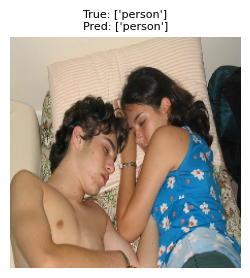

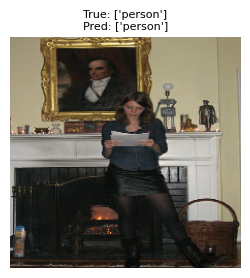

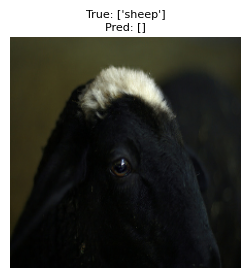

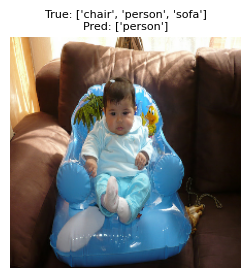

In [17]:
# =========================
# 1.1 Custom CNN from scratch — 3 iterations
# =========================
# Following Ch. 8 of Chollet: start simple → overfit → regularise → add advanced features.

NUM_CLASSES = len(_VOC_LABELS)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Shared helper: plot training curves
def plot_history(history, title=""):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, h["loss"], label="train"); ax1.plot(epochs, h["val_loss"], label="val")
    ax1.set(title=f"{title} Loss", xlabel="Epoch", ylabel="Loss"); ax1.legend()
    if "auc" in h:
        ax2.plot(epochs, h["auc"], label="train"); ax2.plot(epochs, h["val_auc"], label="val")
        ax2.set(title=f"{title} AUC", xlabel="Epoch", ylabel="AUC"); ax2.legend()
    plt.tight_layout(); plt.show()

# Shared callbacks — increased patience so models have time to converge
def get_callbacks(name):
    return [
        keras.callbacks.EarlyStopping(monitor="val_auc", patience=6, mode="max",
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=3,
                                          min_lr=1e-6, mode="max", verbose=1),
        keras.callbacks.ModelCheckpoint(f"{name}.keras", monitor="val_auc", mode="max",
                                        save_best_only=True, verbose=1),
    ]

# Fresh metrics for each model to avoid shared-state issues
def get_metrics():
    return [
        keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc", multi_label=True),
    ]

EPOCHS = 25  # Increased from 15 — give models enough room to learn

# --- Iteration 1: Simple baseline (deliberately prone to overfitting) ---
model_v1 = keras.Sequential([
    keras.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="sigmoid"),
], name="v1_baseline")

model_v1.compile(optimizer="adam", loss="binary_crossentropy", metrics=get_metrics())
model_v1.summary()
h1 = model_v1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=get_callbacks("v1"))
plot_history(h1, "V1 Baseline")

# --- Iteration 2: Add augmentation, batch norm, dropout ---
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

inputs = keras.Input(shape=INPUT_SHAPE)
x = data_aug(inputs)
for filters in [32, 64, 128, 256]:
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.15)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)
model_v2 = keras.Model(inputs, outputs, name="v2_regularized")

model_v2.compile(optimizer="adam", loss="binary_crossentropy", metrics=get_metrics())
model_v2.summary()
h2 = model_v2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=get_callbacks("v2"))
plot_history(h2, "V2 Regularized")

# --- Iteration 3: Depthwise separable convolutions + residual connections ---
def residual_sep_block(x, filters, downsample=False):
    """Residual block with depthwise separable convolutions (Ch. 9 of Chollet)."""
    shortcut = x
    stride = 2 if downsample else 1
    x = layers.SeparableConv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return layers.Dropout(0.15)(x)

inputs = keras.Input(shape=INPUT_SHAPE)
x = data_aug(inputs)
x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
for filters in [64, 128, 256, 512]:
    x = residual_sep_block(x, filters, downsample=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)
model_v3 = keras.Model(inputs, outputs, name="v3_separable_residual")

model_v3.compile(optimizer="adam", loss="binary_crossentropy", metrics=get_metrics())
model_v3.summary()
h3 = model_v3.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=get_callbacks("v3"))
plot_history(h3, "V3 Separable + Residual")

# --- Compare all 3 iterations ---
print("\n=== Comparison on test set ===")
for name, model in [("V1 Baseline", model_v1), ("V2 Regularized", model_v2), ("V3 Sep+Res", model_v3)]:
    res = model.evaluate(test_ds, return_dict=True, verbose=0)
    print(f"{name:25s} | AUC: {res['auc']:.4f} | Precision: {res['precision']:.4f} | Recall: {res['recall']:.4f}")

# Pick the best model and show some predictions
best_model_1_1 = model_v3  # expected best; change if results differ
for images, targets in test_ds.take(1):
    preds = best_model_1_1.predict(images, verbose=0)
    for i in range(min(4, len(images))):
        true_cls = [list(_VOC_LABELS)[j] for j in np.where(targets[i].numpy() > 0.5)[0]]
        pred_cls = [list(_VOC_LABELS)[j] for j in np.where(preds[i] > 0.5)[0]]
        plt.figure(figsize=(3, 3))
        plt.imshow(images[i].numpy()); plt.axis("off")
        plt.title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=8); plt.show()

### 1.2. Feature extraction and fine-tuning

Use the Xception classifier to extract features and as a pretrained model. Feel free to reuse code from the book, but make sure you understand it first.

1. Use features extracted from the Xception classifier and a standalone classifier to classify the images (as explained in section 8.3.1).
Iterate at most 3 times on your dense network architecture choice (and briefly explain your choices). Discuss the results.
Hint: pre-trained networks expect the input images to be preprocessed in a certain way.

2. Build an image classifier by extending Xception’s convolutional base with a dense classification layer (as explained in section 8.3.1). Discuss the results.

3. Using the classifier built in the previous step as a starting point, fine-tune the last block of the convolutional base of the Xception network (as explained in section 8.3.2). Discuss the results.
Tip: Lower the learning rate for RMSprop for better results. Try lowering the learning rate. (you can play around with the values a bit, but no need for a full hyper-parameter search) Also remember to use preprocessing.

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting features with frozen Xception...
322/322 ━━━━━━━━━━━━━━━━━━━━ 152s 356ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 50s 469ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 290ms/step
Feature shape: (10275, 2048)
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.5005 - loss: 0.2517
Epoch 1: val_auc improved from None to 0.48523, saving model to 1_2_head_v1.keras

Epoch 1: finished saving model to 1_2_head_v1.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - auc: 0.5004 - loss: 0.2215 - val_auc: 0.4852 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 2/15
141/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5443 - loss: 0.2049
Epoch 2: val_auc did not improve from 0.48523
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.5541 - loss: 0.2040 - val_auc: 0.4592 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 3/15
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6027 - loss: 0.1986
Epoch 3: val_auc did not improve from 0.48523
161/161 ━━

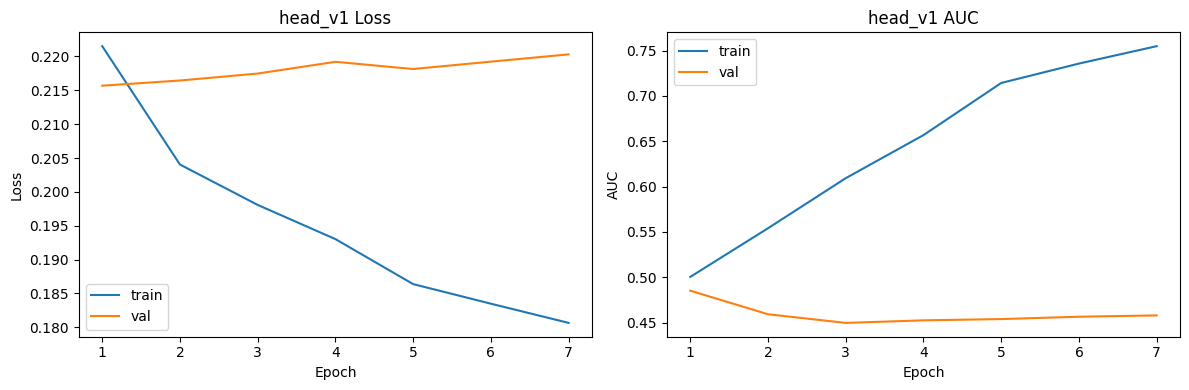

Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.5020 - loss: 0.2560
Epoch 1: val_auc improved from None to 0.46915, saving model to 1_2_head_v2.keras

Epoch 1: finished saving model to 1_2_head_v2.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - auc: 0.5008 - loss: 0.2228 - val_auc: 0.4691 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 2/15
152/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5195 - loss: 0.2071
Epoch 2: val_auc did not improve from 0.46915
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5274 - loss: 0.2061 - val_auc: 0.4465 - val_loss: 0.2109 - learning_rate: 0.0010
Epoch 3/15
153/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5489 - loss: 0.2033
Epoch 3: val_auc did not improve from 0.46915
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5538 - loss: 0.2028 - val_auc: 0.4377 - val_loss: 0.2113 - learning_rate: 0.0010
Epoch 4/15
147/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5756 - loss: 0.2008
Epoch 4: ReduceLROnPlateau reducing learning rate to 0

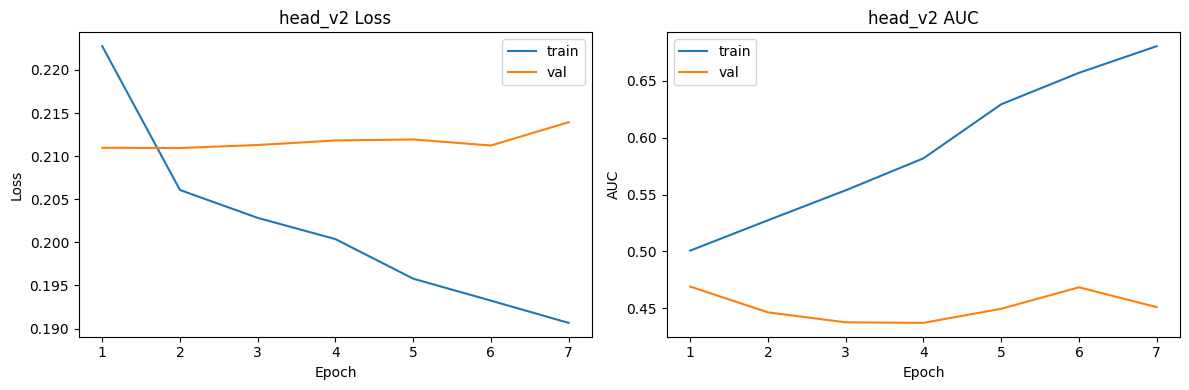

Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.5070 - loss: 0.2704
Epoch 1: val_auc improved from None to 0.47088, saving model to 1_2_head_v3.keras

Epoch 1: finished saving model to 1_2_head_v3.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - auc: 0.5051 - loss: 0.2322 - val_auc: 0.4709 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 2/15
149/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5083 - loss: 0.2126
Epoch 2: val_auc did not improve from 0.47088
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5117 - loss: 0.2114 - val_auc: 0.4670 - val_loss: 0.2087 - learning_rate: 0.0010
Epoch 3/15
147/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5305 - loss: 0.2078
Epoch 3: val_auc improved from 0.47088 to 0.48161, saving model to 1_2_head_v3.keras

Epoch 3: finished saving model to 1_2_head_v3.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5296 - loss: 0.2077 - val_auc: 0.4816 - val_loss: 0.2075 - learning_rate: 0.0010
Epoch 4/15
146/161 ━━━━━━━━━━━━━━━━━━━━ 0s 

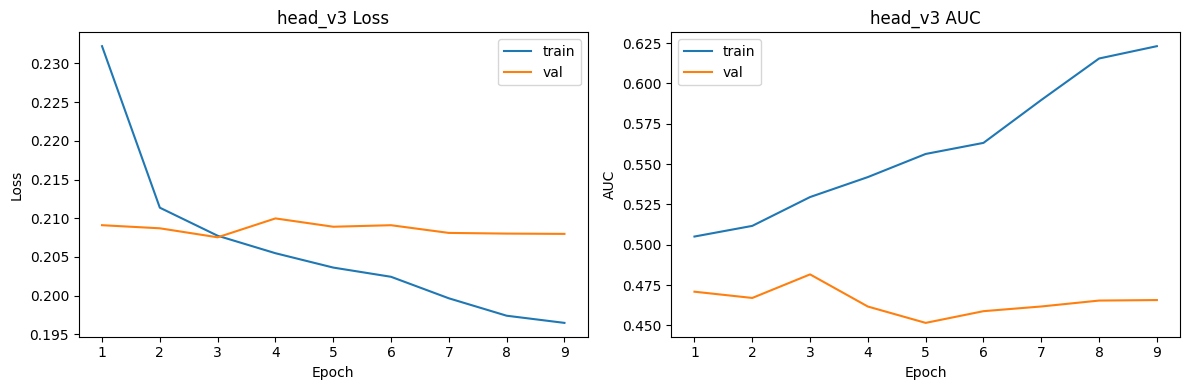

Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - auc: 0.8211 - loss: 0.1558
Epoch 1: val_auc improved from None to 0.95735, saving model to 1_2_frozen.keras

Epoch 1: finished saving model to 1_2_frozen.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 180s 508ms/step - auc: 0.9134 - loss: 0.1064 - val_auc: 0.9574 - val_loss: 0.0774 - learning_rate: 0.0010
Epoch 2/10
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - auc: 0.9600 - loss: 0.0719
Epoch 2: val_auc improved from 0.95735 to 0.95805, saving model to 1_2_frozen.keras

Epoch 2: finished saving model to 1_2_frozen.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 391ms/step - auc: 0.9615 - loss: 0.0721 - val_auc: 0.9581 - val_loss: 0.0742 - learning_rate: 0.0010
Epoch 3/10
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - auc: 0.9682 - loss: 0.0666
Epoch 3: val_auc did not improve from 0.95805
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 390ms/step - auc: 0.9687 - loss: 0.0658 - val_auc: 0.9579 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 4/10
321/322 ━━━━━━━━━━━━

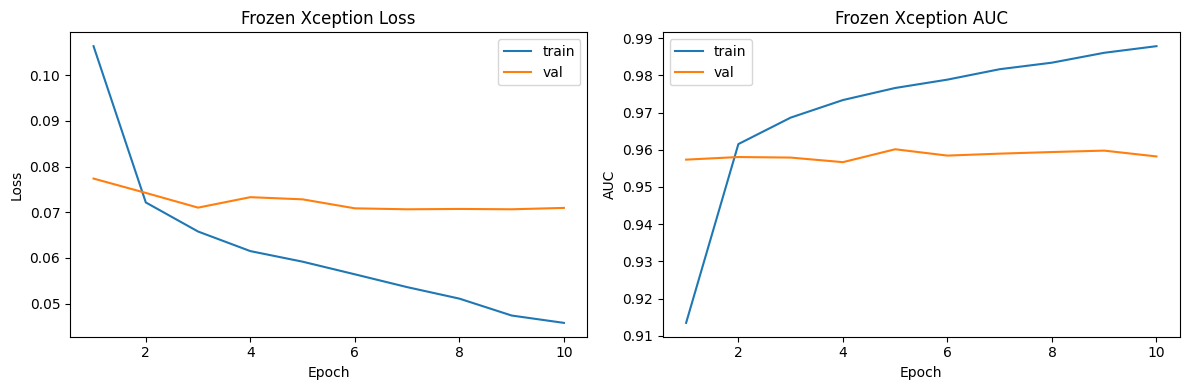

Epoch 1/12
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - auc: 0.9819 - loss: 0.0525
Epoch 1: val_auc improved from None to 0.96110, saving model to 1_2_finetuned.keras

Epoch 1: finished saving model to 1_2_finetuned.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 193s 536ms/step - auc: 0.9838 - loss: 0.0518 - val_auc: 0.9611 - val_loss: 0.0681 - learning_rate: 1.0000e-05
Epoch 2/12
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - auc: 0.9852 - loss: 0.0464
Epoch 2: val_auc improved from 0.96110 to 0.96236, saving model to 1_2_finetuned.keras

Epoch 2: finished saving model to 1_2_finetuned.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 135s 421ms/step - auc: 0.9856 - loss: 0.0480 - val_auc: 0.9624 - val_loss: 0.0676 - learning_rate: 1.0000e-05
Epoch 3/12
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - auc: 0.9856 - loss: 0.0471
Epoch 3: val_auc did not improve from 0.96236
322/322 ━━━━━━━━━━━━━━━━━━━━ 134s 416ms/step - auc: 0.9865 - loss: 0.0463 - val_auc: 0.9614 - val_loss: 0.0674 - learning_rate: 1.0000e-05
Epoch 4

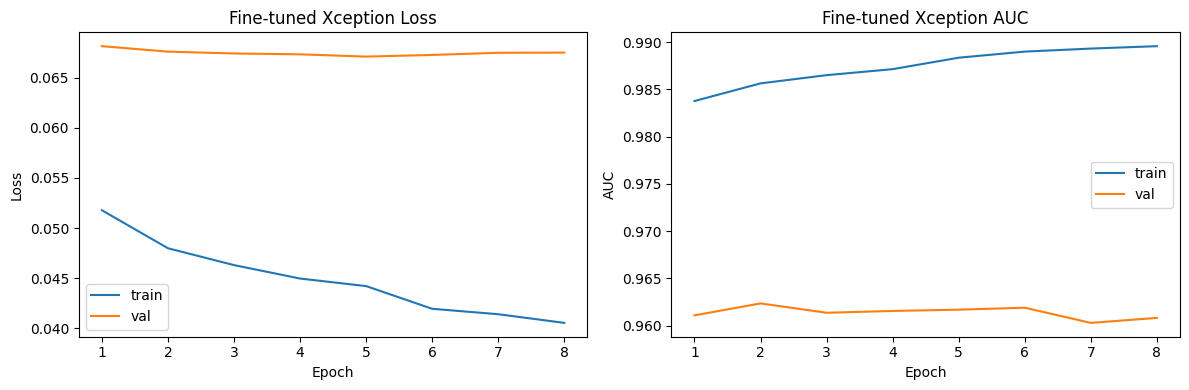


=== Part 1.2 Summary ===
Best standalone head AUC: 0.4951
Frozen-base AUC:          0.9657
Fine-tuned AUC:           0.9682


In [18]:
# ==========================================
# 1.2 Xception feature extraction + fine-tuning  (Ch. 8.3 of Chollet)
# ==========================================

# Xception was designed for 299×299 — using anything smaller loses significant information
XCEPTION_SIZE = 299

# --- Xception-compatible data pipeline ---
# IMPORTANT: pre-trained networks expect specific preprocessing (Chollet Ch. 8.3.1)
def load_xception_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (XCEPTION_SIZE, XCEPTION_SIZE))
    img = keras.applications.xception.preprocess_input(tf.cast(img, tf.float32))
    return img, label

def build_xception_ds(paths, labels, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    return ds.map(load_xception_image, num_parallel_calls=tf.data.AUTOTUNE)\
             .batch(batch_size).prefetch(tf.data.AUTOTUNE)

xc_train = build_xception_ds(train_paths, train_labels, shuffle=True)
xc_val   = build_xception_ds(val_paths, val_labels)
xc_test  = build_xception_ds(test_paths, test_labels)

# ---- Step 1: Extract features with frozen Xception (section 8.3.1) ----
conv_base = keras.applications.Xception(weights="imagenet", include_top=False,
                                         input_shape=(XCEPTION_SIZE, XCEPTION_SIZE, 3))
conv_base.trainable = False

# Build a proper feature extractor model (instead of creating GAP layer per batch)
feat_extractor = keras.Model(
    conv_base.input,
    layers.GlobalAveragePooling2D()(conv_base.output),
    name="xception_feature_extractor"
)

print("Extracting features with frozen Xception...")
train_feats = feat_extractor.predict(xc_train, verbose=1)
val_feats   = feat_extractor.predict(xc_val, verbose=1)
test_feats  = feat_extractor.predict(xc_test, verbose=1)
train_labs, val_labs, test_labs = train_labels, val_labels, test_labels
print(f"Feature shape: {train_feats.shape}")

# ---- 3 iterations of standalone dense heads ----
head_configs = [
    ("head_v1", [layers.Dense(256, activation="relu")]),
    ("head_v2", [layers.Dense(512, activation="relu"), layers.Dropout(0.4),
                 layers.Dense(256, activation="relu")]),
    ("head_v3", [layers.Dense(512, activation="relu"), layers.Dropout(0.5),
                 layers.Dense(256, activation="relu"), layers.Dropout(0.3)]),
]

best_head_auc, best_head = 0, None

for name, head_layers in head_configs:
    inp = keras.Input(shape=(train_feats.shape[1],))
    x = inp
    for l in head_layers:
        x = l(x)
    out = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)
    head = keras.Model(inp, out, name=name)

    head.compile(optimizer="adam", loss="binary_crossentropy",
                 metrics=[keras.metrics.AUC(name="auc", multi_label=True)])

    h = head.fit(train_feats, train_labs, validation_data=(val_feats, val_labs),
                 epochs=15, batch_size=64,
                 callbacks=get_callbacks(f"1_2_{name}"), verbose=1)
    test_res = head.evaluate(test_feats, test_labs, return_dict=True, verbose=0)
    print(f"{name} — test AUC: {test_res['auc']:.4f}")
    plot_history(h, name)

    if test_res["auc"] > best_head_auc:
        best_head_auc, best_head = test_res["auc"], head

# ---- Step 2: End-to-end model with frozen Xception base (section 8.3.1) ----
inputs = keras.Input(shape=(XCEPTION_SIZE, XCEPTION_SIZE, 3))
x = conv_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)
frozen_model = keras.Model(inputs, outputs, name="xception_frozen")

frozen_model.compile(optimizer="adam", loss="binary_crossentropy",
                     metrics=[keras.metrics.AUC(name="auc", multi_label=True)])
h_frozen = frozen_model.fit(xc_train, validation_data=xc_val, epochs=10,
                            callbacks=get_callbacks("1_2_frozen"), verbose=1)
frozen_test = frozen_model.evaluate(xc_test, return_dict=True, verbose=0)
print(f"Frozen-base test AUC: {frozen_test['auc']:.4f}")
plot_history(h_frozen, "Frozen Xception")

# ---- Step 3: Fine-tune last block of Xception (section 8.3.2) ----
# Unfreeze only block14 (keep BatchNorm frozen as recommended by Chollet)
conv_base.trainable = True
for layer in conv_base.layers:
    layer.trainable = layer.name.startswith("block14") and \
                      not isinstance(layer, layers.BatchNormalization)

# Use a MUCH lower learning rate for fine-tuning (book recommends 1e-5 or lower)
frozen_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="binary_crossentropy",
                     metrics=[keras.metrics.AUC(name="auc", multi_label=True)])
h_ft = frozen_model.fit(xc_train, validation_data=xc_val, epochs=12,
                        callbacks=get_callbacks("1_2_finetuned"), verbose=1)
ft_test = frozen_model.evaluate(xc_test, return_dict=True, verbose=0)
print(f"Fine-tuned test AUC: {ft_test['auc']:.4f}")
plot_history(h_ft, "Fine-tuned Xception")

# ---- Summary ----
print("\n=== Part 1.2 Summary ===")
print(f"Best standalone head AUC: {best_head_auc:.4f}")
print(f"Frozen-base AUC:          {frozen_test['auc']:.4f}")
print(f"Fine-tuned AUC:           {ft_test['auc']:.4f}")

# 2. Image segmentation

## Preprocessing


In [19]:

from PIL import Image
import numpy as np
import tensorflow as tf
import os

def get_segmentation_paths(base_dir):
    image_dir = os.path.join(base_dir, "JPEGImages")
    annotation_dir = os.path.join(base_dir, "SegmentationClass")
    lists_dir = os.path.join(base_dir, "ImageSets", "Segmentation")

    image_files_paths = []
    annotation_paths = []

    names = []
    with open(os.path.join(lists_dir, "trainval.txt")) as f:
        for line in f:
            names.append(line.strip())

    for name in names:
        image_files_paths.append(os.path.join(image_dir, f"{name}.jpg"))
        annotation_paths.append(os.path.join(annotation_dir, f"{name}.png"))

    return image_files_paths, annotation_paths

def load_image_and_mask(im_path, mask_path):
    # tf.py_function passes eager tensors; convert to Python strings
    im_path = im_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    img = Image.open(im_path).convert("RGB").resize(_IMAGE_SHAPE, resample=Image.Resampling.BILINEAR)
    # IMPORTANT: masks must use nearest-neighbour resizing to avoid creating fake labels
    mask = Image.open(mask_path).resize(_IMAGE_SHAPE, resample=Image.Resampling.NEAREST)

    img_array = np.array(img).astype(np.float32)
    mask_array = np.array(mask).astype(np.uint8)

    # VOC segmentation masks can be RGB-like arrays after PIL conversion; keep a single channel
    if mask_array.ndim == 3:
        mask_array = mask_array[..., 0]

    # Binary foreground-vs-background segmentation:
    # background = 0, foreground = classes 1..20, border/void label 255 treated as background
    mask_array = ((mask_array > 0) & (mask_array < 255)).astype(np.uint8)

    return img_array, mask_array


In [20]:
image_paths, annotation_paths = get_segmentation_paths(path_to_VOC_folder)


In [21]:
# create train, val and test sets
# for example: 60% train, 20% val, 20% test
from sklearn.model_selection import train_test_split

# Ensure the path retrieval function is called to define the variables
image_paths, annotation_paths = get_segmentation_paths(path_to_VOC_folder)

X_train, X_rest, y_train, y_rest = train_test_split(
    image_paths,
    annotation_paths,
    train_size=0.6,
    shuffle=True,
    random_state=2022
)

X_val, X_test, y_val, y_test = train_test_split(
    X_rest,
    y_rest,
    train_size=0.5,
    shuffle=True,
    random_state=2022
)

print(f'train samples: {len(X_train)} \nval samples: {len(X_val)} \ntest samples: {len(X_test)}')

train samples: 1747 
val samples: 583 
test samples: 583


In [22]:
# create a quick preview dataset
ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
ds = ds.shuffle(buffer_size=min(2000, len(X_train)), seed=42)
ds = ds.map(
    lambda x, y: tf.py_function(
        func=load_image_and_mask,
        inp=[x, y],
        Tout=(tf.float32, tf.uint8),
    ),
    num_parallel_calls=tf.data.AUTOTUNE,
)
ds = ds.map(
    lambda img, mask: (
        tf.ensure_shape(img, [_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 3]),
        tf.ensure_shape(mask, [_IMAGE_SHAPE[0], _IMAGE_SHAPE[1]]),
    ),
    num_parallel_calls=tf.data.AUTOTUNE,
)
ds = ds.batch(_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


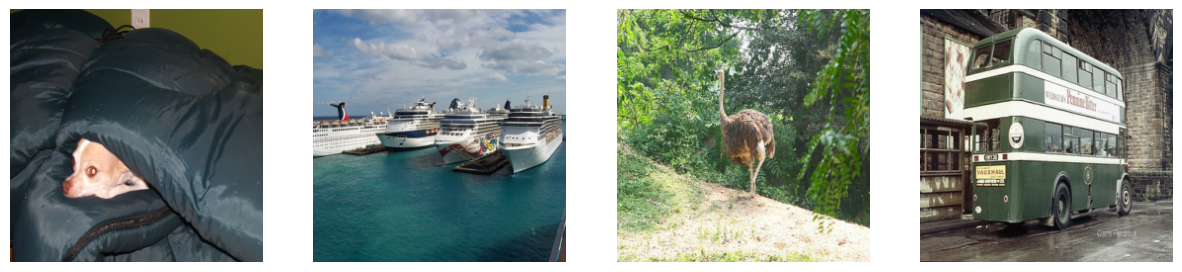

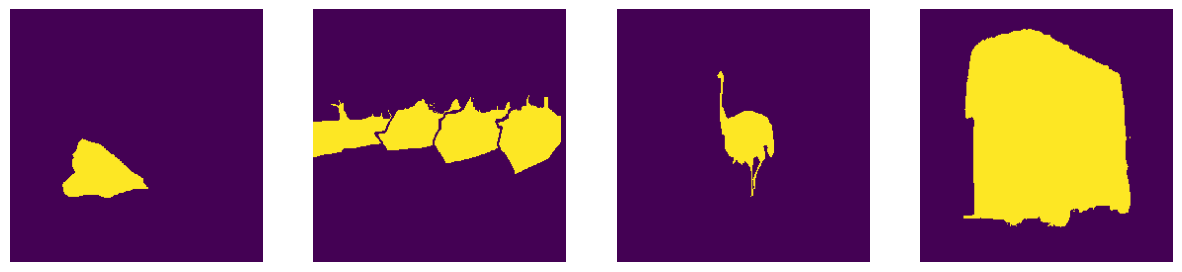

In [23]:
# Display some examples

x,y = iter(ds).next()
plt.figure(figsize=(15,15))
for i in range(4):
  ax=plt.subplot(1,4,i+1)
  ax.imshow(x[i].numpy().astype('uint8'))
  ax.axis('off')
plt.show()
plt.figure(figsize=(15,15))
for i in range(4):
  ax=plt.subplot(1,4,i+1)
  ax.imshow(y[i].numpy().astype('uint8'))
  ax.axis('off')
plt.show()

## Model

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 256, 256,  │      9,216 │ activation_13[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 128, 128,  │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │     36,864 │ activation_15[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ activation_16[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_20[0][0] 

 Total params: 7,768,929 (29.64 MB)

 Trainable params: 7,763,041 (29.61 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.6915 - dice_coef: 0.4268 - iou_score: 0.2994 - loss: 1.2322
Epoch 1: val_dice_coef improved from None to 0.45806, saving model to seg_unet.keras

Epoch 1: finished saving model to seg_unet.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 137s 735ms/step - accuracy: 0.7264 - dice_coef: 0.4633 - iou_score: 0.3313 - loss: 1.1567 - val_accuracy: 0.7183 - val_dice_coef: 0.4581 - val_iou_score: 0.3310 - val_loss: 3.6197 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7567 - dice_coef: 0.5091 - iou_score: 0.3749 - loss: 1.0619
Epoch 2: val_dice_coef did not improve from 0.45806
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 413ms/step - accuracy: 0.7603 - dice_coef: 0.5051 - iou_score: 0.3712 - loss: 1.0570 - val_accuracy: 0.7524 - val_dice_coef: 0.3876 - val_iou_score: 0.2688 - val_loss: 1.4590 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7769 - dice_coef: 0.5261

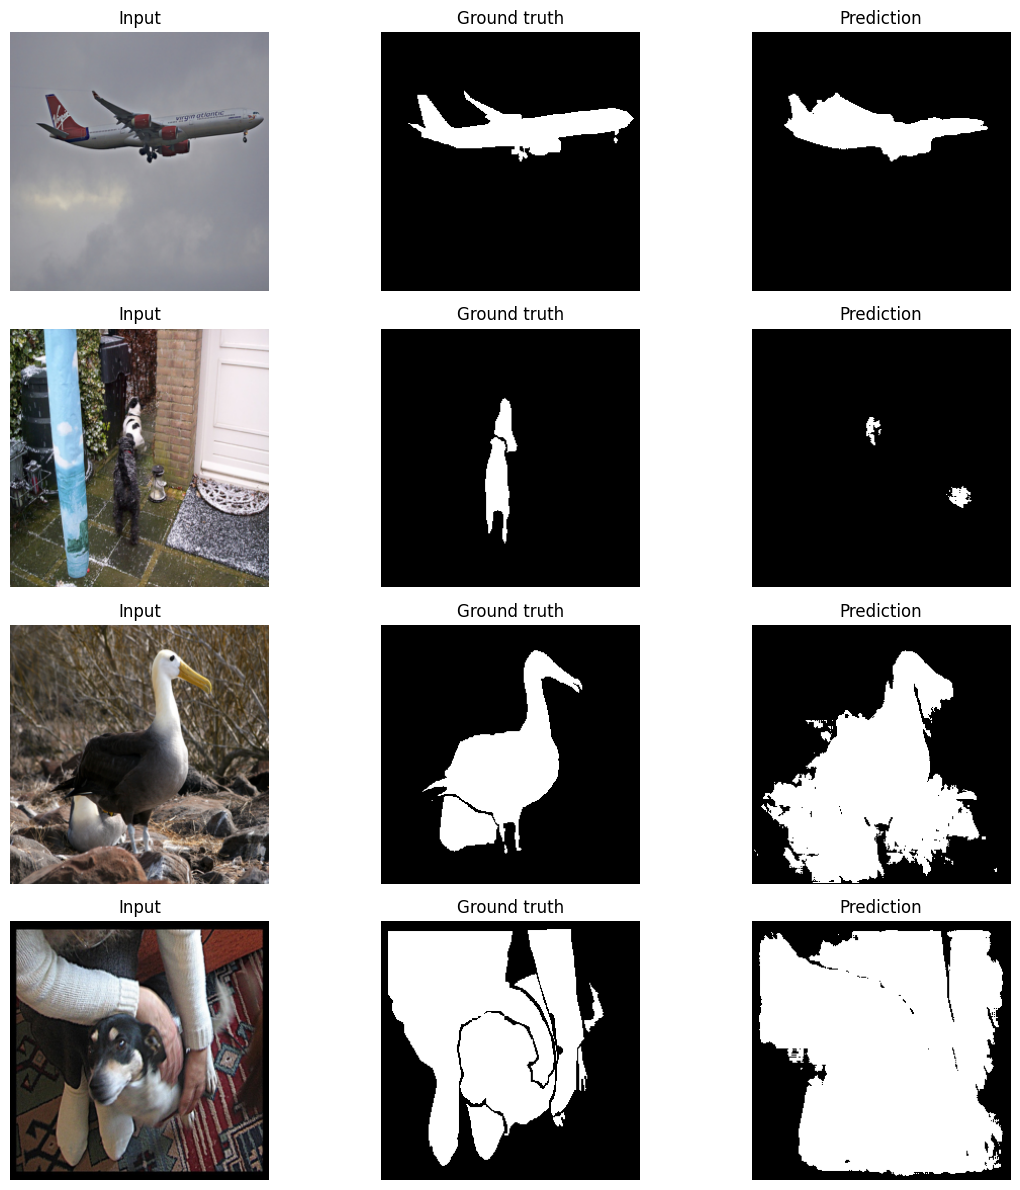

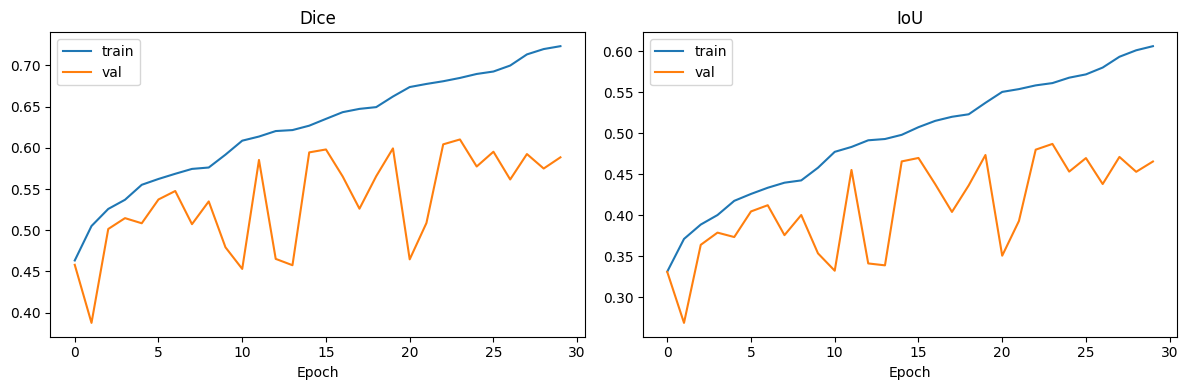


Metrics discussion:
• Dice: standard overlap metric for segmentation, ranges [0,1].
• IoU (Jaccard): stricter than Dice; standard in VOC/COCO benchmarks.
• Pixel accuracy is easy but misleading when background dominates.
• Precision/Recall per pixel give a more balanced view of FP/FN.


In [24]:
# =========================
# Part 2: U-Net for binary segmentation (Ch. 9 of Chollet / TF tutorial)
# =========================

SEG_BATCH = 16

# --- Custom metrics ---
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    total = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    return tf.reduce_mean((2 * inter + smooth) / (total + smooth))

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + smooth) / (union + smooth))

def bce_dice_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    y_t, y_p = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    inter = tf.reduce_sum(y_t * y_p, axis=[1,2,3])
    total = tf.reduce_sum(y_t, axis=[1,2,3]) + tf.reduce_sum(y_p, axis=[1,2,3])
    return tf.reduce_mean(bce) + 1.0 - tf.reduce_mean((2 * inter + 1e-6) / (total + 1e-6))

# --- Data pipeline ---
def set_shapes(img, mask):
    img.set_shape([_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 3])
    mask.set_shape([_IMAGE_SHAPE[0], _IMAGE_SHAPE[1]])
    return img / 255.0, tf.expand_dims(tf.cast(mask, tf.float32), -1)

def augment_seg(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    img = tf.image.random_brightness(img, 0.08)
    return tf.clip_by_value(img, 0, 1), mask

def build_seg_ds(paths, masks, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, masks))
    if shuffle: ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(lambda x, y: tf.py_function(load_image_and_mask, [x, y], (tf.float32, tf.uint8)),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(set_shapes, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(augment_seg, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(SEG_BATCH).prefetch(tf.data.AUTOTUNE)

train_seg = build_seg_ds(X_train, y_train, shuffle=True, augment=True)
val_seg   = build_seg_ds(X_val, y_val)
test_seg  = build_seg_ds(X_test, y_test)

# --- U-Net model ---
def conv_block(x, filters):
    for _ in range(2):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape=(_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 3)):
    inputs = keras.Input(shape=input_shape)
    # Encoder
    skips = []
    x = inputs
    for f in [32, 64, 128, 256]:
        x = conv_block(x, f)
        skips.append(x)
        x = layers.MaxPooling2D()(x)
    # Bottleneck
    x = conv_block(x, 512)
    # Decoder
    for f, skip in zip([256, 128, 64, 32], reversed(skips)):
        x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
        if x.shape[1:3] != skip.shape[1:3]:
            x = layers.Resizing(skip.shape[1], skip.shape[2])(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, f)
    return keras.Model(inputs, layers.Conv2D(1, 1, activation="sigmoid")(x), name="unet")

seg_model = build_unet()
seg_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss,
                  metrics=["accuracy", dice_coef, iou_score])
seg_model.summary()

# --- Train (more epochs + patience to let the model converge properly) ---
seg_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_dice_coef", patience=6, mode="max",
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_dice_coef", factor=0.5, patience=3,
                                      min_lr=1e-6, mode="max", verbose=1),
    keras.callbacks.ModelCheckpoint("seg_unet.keras", monitor="val_dice_coef", mode="max",
                                    save_best_only=True, verbose=1),
]
h_seg = seg_model.fit(train_seg, validation_data=val_seg, epochs=30, callbacks=seg_callbacks, verbose=1)

# --- Evaluate ---
seg_test = seg_model.evaluate(test_seg, return_dict=True, verbose=1)
print("\nTest metrics:")
for k, v in seg_test.items(): print(f"  {k}: {v:.4f}")

# --- Visualise predictions vs ground truth ---
for imgs, masks in test_seg.take(1):
    preds = (seg_model.predict(imgs, verbose=0) > 0.5).astype("float32")
    fig, axes = plt.subplots(4, 3, figsize=(12, 12))
    for i in range(min(4, len(imgs))):
        axes[i, 0].imshow(imgs[i]); axes[i, 0].set_title("Input"); axes[i, 0].axis("off")
        axes[i, 1].imshow(masks[i, ..., 0], cmap="gray"); axes[i, 1].set_title("Ground truth"); axes[i, 1].axis("off")
        axes[i, 2].imshow(preds[i, ..., 0], cmap="gray"); axes[i, 2].set_title("Prediction"); axes[i, 2].axis("off")
    plt.tight_layout(); plt.show()

# --- Training curves ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(h_seg.history["dice_coef"], label="train"); a1.plot(h_seg.history["val_dice_coef"], label="val")
a1.set(title="Dice", xlabel="Epoch"); a1.legend()
a2.plot(h_seg.history["iou_score"], label="train"); a2.plot(h_seg.history["val_iou_score"], label="val")
a2.set(title="IoU", xlabel="Epoch"); a2.legend()
plt.tight_layout(); plt.show()

print("\nMetrics discussion:")
print("• Dice: standard overlap metric for segmentation, ranges [0,1].")
print("• IoU (Jaccard): stricter than Dice; standard in VOC/COCO benchmarks.")
print("• Pixel accuracy is easy but misleading when background dominates.")
print("• Precision/Recall per pixel give a more balanced view of FP/FN.")

# 3. Image detection
## Loading the data

In [25]:
import os
import xml.etree.ElementTree as ET

def preprocess_detection_data(voc_root_folder):

    annotation_dir = os.path.join(voc_root_folder, "Annotations")
    image_dir = os.path.join(voc_root_folder, "JPEGImages")

    dataset = {}

    for xml_file in os.listdir(annotation_dir):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(annotation_dir, xml_file)

        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find("filename").text
        image_id = os.path.splitext(filename)[0]

        image_path = os.path.join(image_dir, filename)

        size = root.find("size")
        width = int(size.find("width").text)
        height = int(size.find("height").text)

        boxes = []
        labels = []

        for obj in root.findall("object"):

            label = obj.find("name").text

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            # Convert to relative coordinates
            rel_x = xmin / width
            rel_y = ymin / height
            box_width = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            boxes.append([rel_x, rel_y, box_width, box_height])
            labels.append(label)

        dataset[image_id] = {
            "boxes": boxes,
            "labels": labels,
            "path": image_path
        }

    return dataset


In [26]:
annotations = preprocess_detection_data(path_to_VOC_folder)

Let's explore the resulting dataset.

In [27]:
# Ensure annotations are loaded
if 'annotations' not in globals():
    annotations = preprocess_detection_data(path_to_VOC_folder)

# Number of images
print(f"Number of images: {len(annotations)}")

# Number of boxes per image
boxes_per_image = [len(v['boxes']) for v in annotations.values()]

min_boxes = min(boxes_per_image)
max_boxes = max(boxes_per_image)
mean_boxes = np.mean(boxes_per_image)

print(f"Min boxes per image: {min_boxes}")
print(f"Max boxes per image: {max_boxes}")
print(f"Mean boxes per image: {mean_boxes:.2f}")

all_labels = []
for v in annotations.values():
    all_labels.extend(v['labels'])

unique_classes = sorted(set(all_labels))

print(f"Number of classes: {len(unique_classes)}")
print("Classes:", unique_classes)

print(f"\nFirst key sample:")
first_key = list(annotations.keys())[0]
print(f"ID: {first_key}")
print(annotations[first_key])

Number of images: 17125
Min boxes per image: 1
Max boxes per image: 56
Mean boxes per image: 2.34
Number of classes: 20
Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

First key sample:
ID: 2008_000107
{'boxes': [[0.1642512077294686, 0.424, 0.5314009661835749, 0.54]], 'labels': ['chair'], 'path': '/content/voc/VOCdevkit/VOC2012/JPEGImages/2008_000107.jpg'}


In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle

color_map = {0: "gray"}

def label_to_color(label):
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = hsv_to_rgb((h, s, v))
    return color_map[label]

def draw_box(ax, box, text, color):
    x, y, w, h = box
    ax.add_patch(Rectangle((x, y), w, h, lw=2, ec=color, fc="none"))
    textbox = dict(fc=color, pad=1, ec="none")
    ax.text(x, y, text, c="white", size=10, va="bottom", bbox=textbox)

def draw_image(ax, image):
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

In [29]:
sample = annotations["2007_000733"]
print(sample)

{'boxes': [[0.10666666666666667, 0.05747126436781609, 0.5, 0.8229885057471265], [0.2288888888888889, 0.46206896551724136, 0.7666666666666667, 0.5379310344827586]], 'labels': ['person', 'motorbike'], 'path': '/content/voc/VOCdevkit/VOC2012/JPEGImages/2007_000733.jpg'}


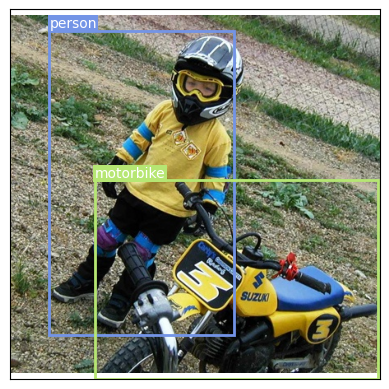

In [30]:
ig, ax = plt.subplots(dpi=100)
draw_image(ax, sample["path"])
for box, label in zip(sample["boxes"], sample["labels"]):
    draw_box(ax, box, label, label_to_color(label))

plt.show()

## Preprocessing the data

Now it's your turn to preprocess the data so that you can feed it to the object detection algorithm. You can head to the book for inspiration, but make sure you understand your code.

In [31]:
# ==========================================
# Part 3: Preprocess data for object detection
# ==========================================
import xml.etree.ElementTree as ET
import keras_cv

VOC_CLASSES = list(_VOC_LABELS)
CLASS_TO_ID = {name: i for i, name in enumerate(VOC_CLASSES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

BBOX_FORMAT = "rel_xywh"   # boxes are normalised
DET_IMG_SIZE = (416, 416)   # Increased from 320 — standard YOLO input size
DET_BATCH = 8
JPEG_DIR = os.path.join(path_to_VOC_folder, "JPEGImages")
ANN_DIR  = os.path.join(path_to_VOC_folder, "Annotations")
SPLIT_DIR = os.path.join(path_to_VOC_folder, "ImageSets", "Main")

def read_ids(filename):
    with open(os.path.join(SPLIT_DIR, filename)) as f:
        return [l.strip() for l in f if l.strip()]

def parse_annotation(img_id):
    tree = ET.parse(os.path.join(ANN_DIR, f"{img_id}.xml"))
    root = tree.getroot()
    sz = root.find("size"); w, h = float(sz.find("width").text), float(sz.find("height").text)
    boxes, classes = [], []
    for obj in root.findall("object"):
        name = obj.find("name").text
        if name not in CLASS_TO_ID: continue
        bb = obj.find("bndbox")
        xmin, ymin = float(bb.find("xmin").text), float(bb.find("ymin").text)
        xmax, ymax = float(bb.find("xmax").text), float(bb.find("ymax").text)
        boxes.append([xmin/w, ymin/h, (xmax-xmin)/w, (ymax-ymin)/h])
        classes.append(CLASS_TO_ID[name])
    return os.path.join(JPEG_DIR, f"{img_id}.jpg"), np.array(boxes, dtype=np.float32), np.array(classes, dtype=np.float32)

def build_arrays(ids):
    paths, all_boxes, all_cls = [], [], []
    for img_id in ids:
        p, b, c = parse_annotation(img_id)
        if len(b) == 0: continue
        paths.append(p); all_boxes.append(b); all_cls.append(c)
    return np.array(paths), all_boxes, all_cls

# Use official VOC splits
train_ids, val_ids = train_test_split(read_ids("train.txt"), test_size=0.1, random_state=SEED)
test_ids = read_ids("val.txt")

det_train_p, det_train_b, det_train_c = build_arrays(train_ids)
det_val_p,   det_val_b,   det_val_c   = build_arrays(val_ids)
det_test_p,  det_test_b,  det_test_c  = build_arrays(test_ids)

MAX_BOXES = max(max(len(b) for b in det_train_b), max(len(b) for b in det_val_b), max(len(b) for b in det_test_b))
print(f"Train: {len(det_train_p)}, Val: {len(det_val_p)}, Test: {len(det_test_p)}, Max boxes: {MAX_BOXES}")

# --- Build tf.data pipelines ---
def load_det_sample(path, boxes, classes):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, DET_IMG_SIZE)
    # CRITICAL FIX: keep pixel values in [0, 255] — YOLO backbone expects this range!
    # The old code used tf.image.convert_image_dtype which scaled to [0,1],
    # causing vanishing activations in the pretrained backbone (model never trains).
    img = tf.cast(img, tf.float32)
    return {"images": img, "bounding_boxes": {"boxes": boxes, "classes": classes}}

def to_dense(inputs):
    dense = keras_cv.bounding_box.to_dense(inputs["bounding_boxes"], max_boxes=MAX_BOXES)
    return inputs["images"], dense

def build_det_ds(paths, boxes, classes, training=False):
    b_rt = tf.ragged.constant(boxes, dtype=tf.float32)
    c_rt = tf.ragged.constant(classes, dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, b_rt, c_rt))
    if training: ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_det_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.ragged_batch(DET_BATCH, drop_remainder=False)
    if training:
        ds = ds.map(keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format=BBOX_FORMAT),
                     num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_dense, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_det = build_det_ds(det_train_p, det_train_b, det_train_c, training=True)
val_det   = build_det_ds(det_val_p, det_val_b, det_val_c)
test_det  = build_det_ds(det_test_p, det_test_b, det_test_c)

for imgs, y in train_det.take(1):
    print("Batch shape:", imgs.shape, "| Boxes:", y["boxes"].shape)
    print(f"Image value range: [{tf.reduce_min(imgs).numpy():.1f}, {tf.reduce_max(imgs).numpy():.1f}]")

Train: 5145, Val: 572, Test: 5823, Max boxes: 56
Batch shape: (8, 416, 416, 3) | Boxes: (8, 56, 4)
Image value range: [0.0, 255.0]


## Model

100%|██████████| 645/645 [00:00<00:00, 1.32MB/s]


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ [(None, None,     │  1,277,680 │ input_layer_11[0… │
│ (Functional)        │ None, 64), (None, │            │                   │
│                     │ None, None, 128), │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional_2[0][… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 384)        │            │ functional_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │     49,152 │ concatenate_9[0]… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 64), (None, │            │                   │
│                     │ None, None, 64)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │     36,864 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        256 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │     36,864 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,436,268 (13.11 MB)

 Trainable params: 3,425,100 (13.07 MB)

 Non-trainable params: 11,168 (43.62 KB)

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - box_loss: 2.8910 - class_loss: 70.9421 - loss: 73.8331
Epoch 1: val_loss improved from None to 3.12245, saving model to det_yolov8.keras

Epoch 1: finished saving model to det_yolov8.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 164s 143ms/step - box_loss: 2.6198 - class_loss: 29.8060 - loss: 32.4660 - val_box_loss: 2.2587 - val_class_loss: 0.8664 - val_loss: 3.1224 - learning_rate: 5.0000e-04
Epoch 2/25
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - box_loss: 2.1388 - class_loss: 0.6233 - loss: 2.7621
Epoch 2: val_loss improved from 3.12245 to 2.41357, saving model to det_yolov8.keras

Epoch 2: finished saving model to det_yolov8.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - box_loss: 2.1059 - class_loss: 0.4902 - loss: 2.5984 - val_box_loss: 2.0924 - val_class_loss: 0.3197 - val_loss: 2.4136 - learning_rate: 5.0000e-04
Epoch 3/25
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - box_loss: 2.0432 - class_loss: 0.2994 - loss: 2.3426
Epoch 3: val

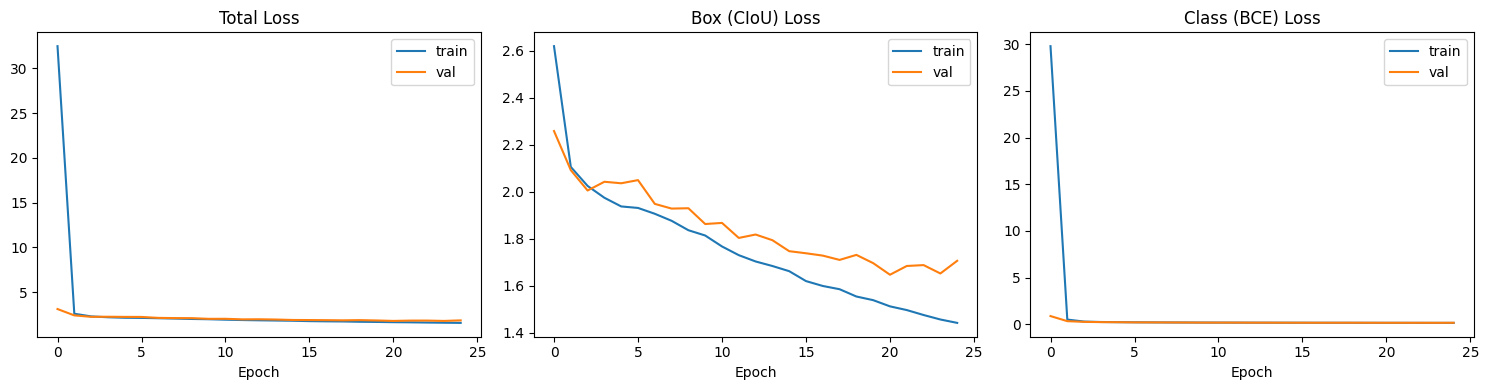

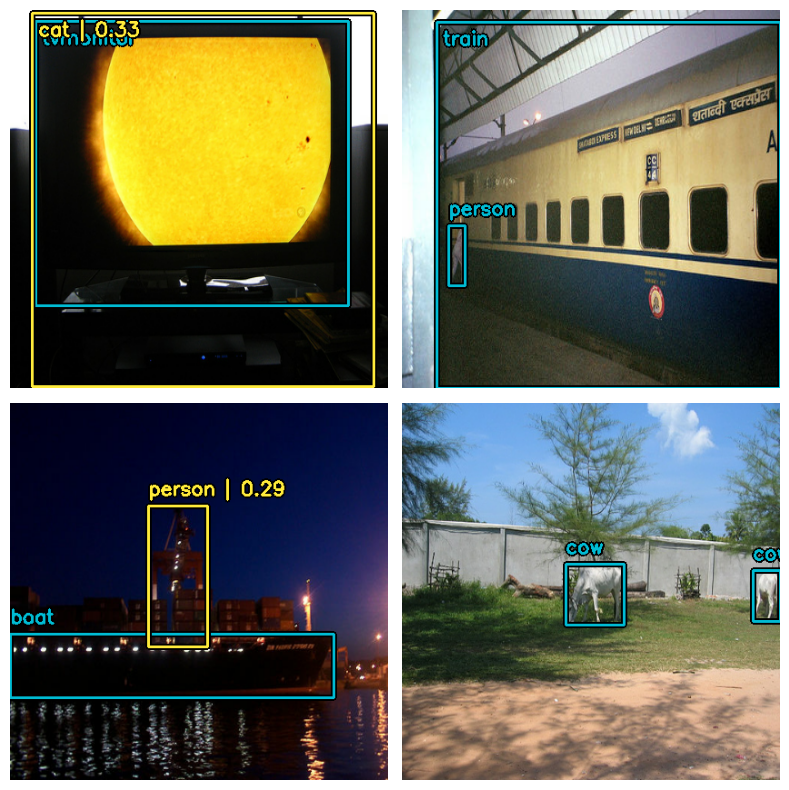

In [32]:
# ==========================================
# Part 3: YOLOv8 Object Detection (book Ch. 9 + keras-cv)
# ==========================================

# --- Build YOLOv8 detector ---
backbone = keras_cv.models.YOLOV8Backbone.from_preset("yolo_v8_xs_backbone_coco")
detector = keras_cv.models.YOLOV8Detector(
    num_classes=len(VOC_CLASSES),
    bounding_box_format=BBOX_FORMAT,
    backbone=backbone,
    fpn_depth=1,
)
detector.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format=BBOX_FORMAT, from_logits=False,
    confidence_threshold=0.25, iou_threshold=0.50,
)
# Lower initial LR (5e-4 instead of 1e-3) — gentler start for pretrained backbone
detector.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4, global_clipnorm=10.0),
    classification_loss="binary_crossentropy",
    box_loss="ciou",
)
detector.summary()

# --- Train (more epochs and patience to let the model converge) ---
det_cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint("det_yolov8.keras", monitor="val_loss", save_best_only=True, verbose=1),
]
h_det = detector.fit(train_det, validation_data=val_det, epochs=25, callbacks=det_cbs, verbose=1)

# --- Evaluate with COCO mAP ---
map_metric = keras_cv.metrics.BoxCOCOMetrics(bounding_box_format=BBOX_FORMAT, evaluate_freq=1e9)
for imgs, y_true in test_det:
    y_pred = detector.predict(imgs, verbose=0)
    map_metric.update_state(y_true, y_pred)
print("\nCOCO metrics:", map_metric.result())

# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "box_loss", "class_loss"], ["Total", "Box (CIoU)", "Class (BCE)"]):
    if key in h_det.history:
        ax.plot(h_det.history[key], label="train"); ax.plot(h_det.history[f"val_{key}"], label="val")
        ax.set(title=f"{title} Loss", xlabel="Epoch"); ax.legend()
plt.tight_layout(); plt.show()

# --- Visualise detections ---
# IMPORTANT: value_range must match the actual image range (0-255, not 0-1)
imgs, y_true = next(iter(test_det.take(1)))
y_pred = detector.predict(imgs, verbose=0)
keras_cv.visualization.plot_bounding_box_gallery(
    imgs, value_range=(0, 255), y_true=y_true, y_pred=y_pred,
    bounding_box_format=BBOX_FORMAT, class_mapping=ID_TO_CLASS,
    rows=2, cols=2, scale=4, font_scale=0.7, show=True,
)